# Case Studies: Applying Mechanistic Interpretability to Pre and Post Training Science

Mechanistic Interpretability was developed to give humans the ability to supervise AI systems in a rigorous quantitative fashion, with the goal of improving our ability to control, verify, and steer the outputs of increasingly powerful machine learning models. 

While the most obvious application of mech interp lies in AI Safety & Existential Risk (which we'll discuss next week) an under-researched and increasingly important application of mech interp techniques is studying learning dynamics with the goal of improving pre and post training science, as well as neural architectures themselves. 

This week we'll study a few recent and highly impactful papers which in this field which, grounding the 


## Case Study 1: Why Gradient Norms Increase Rapidly at the End of Training (https://arxiv.org/pdf/2506.02285)

A well-observed phenomenon in machine learning is that gradient norms increase rapidly near the end of training when both weight-decay and learning rate schedulers are used

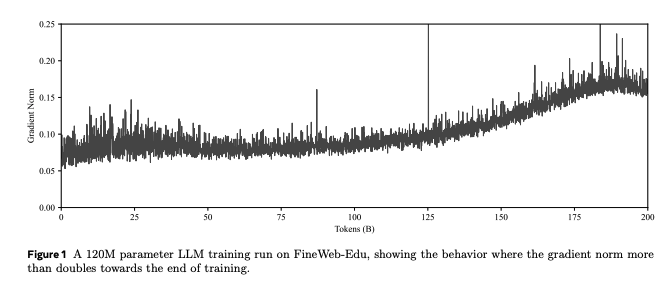

The authors argue that this is due to an unintended interaction between the learning rate $\gamma$ and the weight decay parameter $\lambda$ that emerges when training via AdamW (one of the most common optimizers, though becoming less common since Muon's widespread adoption)

The weight update for vanilla stochastic gradient descent (SGD) is 

$$x_{t+1} = x_t - \gamma g_t - \gamma \lambda x_t$$

Where $g_t$ gives the gradient and $\gamma \lambda x_t$ is the weight decay parameter. Adam (Adaptive Moment Estimation) improves the speed and stability of convergence by approximating second order gradient information via two momentum buffers

$$x_{t+1} = x_t - \gamma \frac{\hat{m}_t + \gamma \lambda x_t}{\sqrt{\hat{v}_t} + \epsilon} $$

Where the momentum buffers $\hat{m}_t$ and $\hat{v}_t$ are given by

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

and $\hat{m}_t$ and $\hat{v}_t$ are debiased terms (meaning we correct for the fact that $m_t$ and $v_t$ are initialized at zero, which biases them toward zero in early steps):

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

One issue with Adam is that the weight decay term $\gamma \lambda x_t$ is present in the numerator of the gradient, which means that we decay weights in proportion to the denominator $\sqrt{\hat{v}_t} + \epsilon$, so weights that have a larger 2nd moment buffer get shrunk less because we're dividing the numerator by a larger denominator. It's been demonstrated empirically that it's usually best in pretraining to uniformly decay model weights. AdamW (Adaptive Moment Estmation with Decoupled Weight Decay) solves this by decoupling the weight decay term from the gradient update

$$x_{t+1} = x_t - \gamma \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \gamma \lambda x_t$$

But this introduces an unintended interaction between the learning rate $\gamma$ and the weight decay parameter $\lambda$. If we assume the layers are normalized beforehand and no momentum buffer is used (so $\hat{m}_t = g_t$), then we get this weight update rule:

$$x_{t+1} = x_t - \gamma_t A_t^{-1} g_t - \gamma_t \lambda x_t$$

Where $A_t^{-1} = \text{diag}(\frac{1}{\sqrt{\hat{v}_t} + \epsilon})$

Now let's look at tte gradient norms at *steady state dynamics* ($x_t \approx x_{t+1}$ and $A_t \approx a_{t+1}$)

$$\|x_{t+1}\|_{A_t}^2 = \|x_t - \gamma A_t^{-1} g_t - \gamma \lambda x_t\|_{A_t}^2$$

$$\|x_{t+1}\|_{A_t}^2 = (1 - \gamma \lambda)^2 \|x_t\|_{A_t}^2 - 2(1 - \gamma \lambda) \gamma \langle A_t^{-1} g_t, A_t x_t \rangle + \gamma^2 \|A_t^{-1} g_t\|_{A_t}^2$$

If we assume $\langle A_t^{-1} g_t, A_t x_t \rangle = 0$ (the gradients and weights are orthogonal because the layer has been normalized), we get this:

$$\|x_{t+1}\|_{A_t}^2 = (1 - \gamma \lambda)^2 \|x_t\|_{A_t}^2 + \gamma^2 \|g_t\|_{A_t^{-1}}^2.$$

$$\|x_t\|_{A_t}^2 \left[1 - (1 - \gamma\lambda)^2\right] = \gamma^2 \|g_t\|_{A_t^{-1}}^2$$

$$\frac{\|g_t\|_{A_t^{-1}}^2}{\|x_t\|_{A_t}^2} \propto \sqrt{\frac{2\lambda}{\gamma_t}}$$


Why does this matter? this ratio is going to *continually increase* throughout training. Thnk about it. The numerator is constant (we don't change the lr decay rate) and the denominator on the right side the equation is decreasing because we're decaying the learning rate as a function of train step. So the left side of the equation blows up. What does this do for gradient norms? Because learning rate is decreasing and weight decay is constant, you can think of us pushing the norm of the model weights $\|x_t\|^2$ towards zero. This drives a corresponding increase in gradient norm as a mathematical result of this equation*. That in turn can lead to instability and inefficiency late in model training. Typically this isn't felt much because the learning rate has decreased enough that parameter updates are small, but it is still felt. 

*(also note that this is *not* merely a correlational relationship. This derivation comes directly from the steady state update rule, meaning this is not a statistical relationship; the model update literally is forced to satisfy this relationship because of how the algebra works)

We can observe this empirically by running a small-scale pretraining run on a NanoGPT using AdamW to drive gradient descent: 

In [6]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

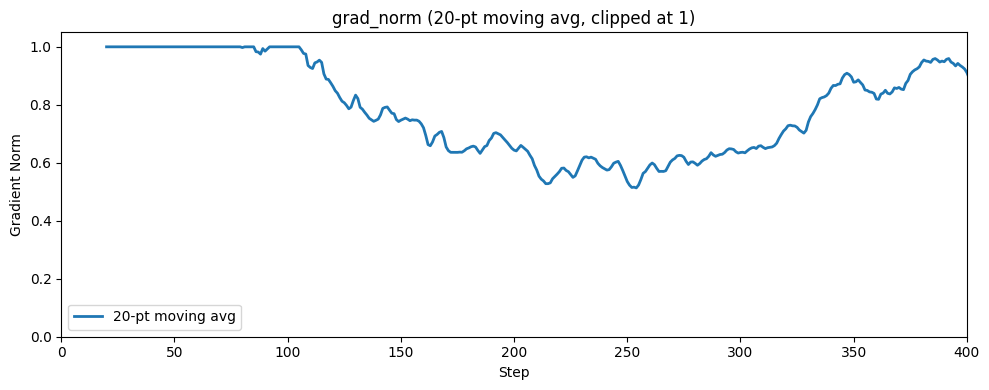

In [8]:
# Pull data from the W&B run
api = wandb.Api()
run = api.run("jaredjunkin-johns-hopkins-university/owt/ta1uydas")
history = run.history(keys=["grad_norm"], pandas=True)

# Compute 20-point moving average and clip to [0, 1]
history["grad_norm_smooth"] = history["grad_norm"].rolling(window=20).mean().clip(upper=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["_step"], history["grad_norm_smooth"], linewidth=2, label="20-pt moving avg")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 400)
ax.set_xlabel("Step")
ax.set_ylabel("Gradient Norm")
ax.set_title("grad_norm (20-pt moving avg, clipped at 1)")
ax.legend()
plt.tight_layout()
plt.show()

We can fix this problem by scaling our weight decay term $\lambda$ according to the learning rate at timestep $t$ $\gamma_t$:

$$\lambda_t = \frac{\gamma_t}{\gamma_\text{max}}$$
Where $\gamma_\text{max}$ gives the max learning rate. If we plug that into the relationship we derived above we get

$$\frac{\|g_t\|_{A_t^{-1}}^2}{\|x_t\|_{A_t}^2} \propto \sqrt{\frac{2\lambda_t}{\gamma_t}} = \sqrt{\frac{2\frac{\gamma_t}{\gamma_\text{max}}}{\gamma_t}} = \sqrt{\frac{2}{\lambda_\text{max}}}$$

And this term is a constant! So that means scaling our weight decay term in proportion to the decreasing learning rate means our gradient norms shouldn't blow up at the end of training. 

## Case Study 2: State-Tracking in LLMs and Gated Linear Recurrent RNNs

Imagine you have 5 cups in front of you, with a coin underneath the center one. The cups are rotated and you need to determine which cup the coin is under at the end. This is the state-tracking problem, and it's become an important benchmark of LLM capabilities in recent years.

One mathematical formulation of the state tracking problem is permutation composition: performing a series of permutations on an initial sequence to reorder it



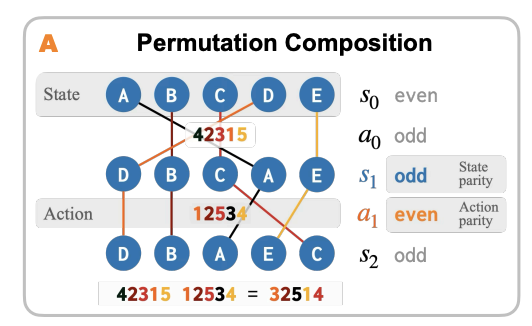


We can express a permutation composition in code like this:

In [2]:
# import modules
from fla.models import GatedDeltaNetConfig, GatedDeltaProductConfig
import fla.models
from transformers import AutoModelForCausalLM
import torch
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
### Now let's git clone the state tracking problem and confirm I can import that
from utils.data_loaders import ChunkedDataset
from utils.data_collators import DataCollatorForLanguageModelingWithNextTokenSupervision
from utils.model_utils import setup_tokenizer
from permutation_task import PermutationTask
from torch.utils.data import DataLoader


Current Triton version 3.1.0 is below the recommended 3.2.0 version. Errors may occur and these issues will not be fixed. Please consider upgrading Triton.


In [7]:
# Look at a single raw example
### load in the dataset
NUM_ITEMS = 5
MAX_LEN = 120
BATCH_SIZE = 256
DATA_DIR = "data/test"

# Create the permutation task (needed for token definitions)
task = PermutationTask(num_items=NUM_ITEMS)
state_tokens = {state.permutation: state.to_string() for state in task.states}
action_tokens = {action.permutation: action.to_string() for action in task.actions}
print("defined permutation task")
dataset = ChunkedDataset(DATA_DIR, max_len=MAX_LEN)
example = dataset[0]
print(f"\nKeys: {list(example.keys())}")
# print(f"\nRaw story text (first 200 chars):\n{example['story'][:200]}")
print(f"\nActions to Apply: {example['story'].split()[:20]} ...")
# print(f"Actions to Apply: {len(example['story'].split())}")
print(F"States (Ground Truth Model Must Track): {example['state_seq'][:20]}")

defined permutation task

Keys: ['story', 'state_seq']

Actions to Apply: ['14352', '25431', '43215', '31542', '15243', '32415', '42153', '43125', '43125', '14532', '53124', '52314', '31245', '45123', '13425', '25431', '32145', '21435', '51243', '45231'] ...
States (Ground Truth Model Must Track): [[1, 2, 3, 4, 5], [1, 4, 3, 5, 2], [4, 2, 5, 3, 1], [3, 5, 2, 4, 1], [2, 3, 1, 4, 5], [2, 5, 3, 4, 1], [3, 5, 4, 2, 1], [2, 5, 3, 1, 4], [1, 3, 2, 5, 4], [5, 2, 1, 3, 4], [5, 3, 4, 1, 2], [2, 4, 5, 3, 1], [1, 4, 5, 2, 3], [5, 1, 4, 2, 3], [2, 3, 5, 1, 4], [2, 5, 1, 3, 4], [5, 4, 3, 1, 2], [3, 4, 5, 1, 2], [4, 3, 1, 5, 2], [2, 4, 3, 5, 1]]


Notice how we can turn this into a next token prediction problem. At each index $t$, the model can be trained to predict `states[t+1]` via the standard categorical crossentropy loss

$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

So we know that, in theory, we can pretrain a LLM to solve this. But what algorithm would it implement in practice? 